# CDO+Python tutorial

**April 16, 2026**

This tutorial is a short introduction to Climate Data Operators (CDO) and its Python bindings.

More resources can be found here:
- User guide (comprehensive reference): https://code.mpimet.mpg.de/projects/cdo/embedded/cdo.pdf
- Cheat sheet (concise reference): https://code.mpimet.mpg.de/projects/cdo/embedded/cdo_refcard.pdf
- Introduction to Python bindings (which this tutorial is loosely based on): https://code.mpimet.mpg.de/attachments/download/27273/python_cdo_introduction.pdf

# Getting started

## Data download

To reproduce the steps from the tutorial, please execute the cells below to download the data. This will download around 200 MB to your disk. (simply reduce the range of years if you'd like to use less)

In [ ]:
import os
import urllib

In [ ]:
os.makedirs("data", exist_ok=True)

In [ ]:
# One year of sea surface temperature data
url_tos = "http://esgf3.dkrz.de/thredds/fileServer/cmip6/ScenarioMIP/EC-Earth-Consortium/EC-Earth3/ssp245/r1i1p1f1/Omon/tos/gn/v20200918/tos_Omon_EC-Earth3_ssp245_r1i1p1f1_gn_202601-202612.nc"
urllib.request.urlretrieve(url_tos, "data/tos_Omon_EC-Earth3_ssp245_r1i1p1f1_gn_202601-202612.nc");

In [ ]:
# 87 years of SSP2-4.5 sea ice concentration data
for year in range(2015,2101):
    url_sic = f"http://esgf3.dkrz.de/thredds/fileServer/cmip6/ScenarioMIP/EC-Earth-Consortium/EC-Earth3/ssp245/r1i1p1f1/SImon/siconc/gn/v20200918/siconc_SImon_EC-Earth3_ssp245_r1i1p1f1_gn_{year:04d}01-{year:04d}12.nc"
    urllib.request.urlretrieve(url_sic, f"data/siconc_SImon_EC-Earth3_ssp245_r1i1p1f1_gn_{year:04d}01-{year:04d}12.nc")
    if year%10 == 0: print(year)
print("Download successful!")

## Setting up CDO (etc.)

There are two ways to make the CDO-Python wrapper work out of the box in this Jupyter notebook:
- A global (i.e., system-wide) CDO installation or
- A CDO installation in the same conda environment as the jupyter notebook/lab package that you're running this notebook from

If this is not the case and you get, e.g., a `FileNotFoundError` running the second cell below, refer to the "Advanced installation instruction" at the end of this notebook.

In [1]:
import cdo as cdopy

In [ ]:
cdo = cdopy.Cdo(tempdir="./tmp")

In [3]:
# Clean up temporary files
cdo.cleanTempDir()

In [4]:
print("python-cdo version:", cdopy.__version__)
print("CDO version:", cdo.version())

python-cdo version: 1.6.0
CDO version: 2.5.0


In [5]:
# It's best to turn debugging on, otherwise you won't see the warnings
cdo.debug = False

Let's also load the other packages that we'll need later

In [6]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean

## Checking the installation

CDO has around 800 operators! This command will give you the full list (which is probably not too useful):

In [7]:
cdo.operators

{'abs': 1,
 'acos': 1,
 'add': 1,
 'addc': 1,
 'addtrend': 1,
 'adipot': 1,
 'adisit': 1,
 'aexpr': 1,
 'aexprf': 1,
 'after': 1,
 'afterburner': 1,
 'anomaly': 1,
 'ap2hl': 1,
 'ap2hlx': 1,
 'ap2pl': 1,
 'ap2plx': 1,
 'arg': 1,
 'asin': 1,
 'atan': 1,
 'atan2': 1,
 'bandpass': 1,
 'bitrounding': 1,
 'bottomvalue': 1,
 'boxavg': 1,
 'cat': 1,
 'cdiread': 0,
 'cdiwrite': 1,
 'changemulti': 1,
 'chcode': 1,
 'chlevel': 1,
 'chlevelc': 1,
 'chlevelv': 1,
 'chltype': 1,
 'chname': 1,
 'chparam': 1,
 'chtabnum': 1,
 'chunit': 1,
 'chvar': 1,
 'clone': 1,
 'cloudlayer': 1,
 'cmor': 0,
 'cmorlite': 1,
 'codetab': 0,
 'collgrid': 1,
 'complextopol': 2,
 'complextorect': 2,
 'conj': 1,
 'consecsum': 1,
 'consects': 1,
 'const': 1,
 'contour': 1,
 'conv_cmor_table': 0,
 'copy': 1,
 'cos': 1,
 'coshill': 1,
 'dayadd': 1,
 'dayavg': 1,
 'daycount': 1,
 'daydiv': 1,
 'daymax': 1,
 'daymean': 1,
 'daymin': 1,
 'daymul': 1,
 'daypctl': 1,
 'dayrange': 1,
 'daystd': 1,
 'daystd1': 1,
 'daysub': 1,
 'd

List all operators starting with "sel"

In [8]:
[key for key, value in cdo.operators.items() if key.startswith('sel')]
#[key for key, value in cdo.operators.items() if key.startswith('ymon')]

['selcircle',
 'selcode',
 'seldate',
 'selday',
 'select',
 'selgrid',
 'selgridcell',
 'selgridname',
 'selhour',
 'selindexbox',
 'sellevel',
 'sellevidx',
 'sellonlatbox',
 'selltype',
 'selmon',
 'selmonth',
 'selmulti',
 'selname',
 'seloperator',
 'selparam',
 'selrec',
 'selregion',
 'selseas',
 'selseason',
 'selsmon',
 'selstdname',
 'seltabnum',
 'seltime',
 'seltimeidx',
 'seltimestep',
 'selvar',
 'selyear',
 'selyearidx',
 'selzaxis',
 'selzaxisname']

## Let's see what's in the data!

In [9]:
fn_tos = glob.glob("data/tos*.nc")[0]

In [10]:
# With CDO
cdo.sinfo(input=fn_tos)

['File format : NetCDF4 classic zip',
 '-1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID',
 '1 : unknown  EC-Earth3 v instant       1   1    105704   1  F32z : -1',
 'Grid coordinates :',
 '1 : curvilinear              : points=105704 (362x292)',
 'longitude : 0.04980469 to 359.9949 degrees_east',
 'latitude : -78.57995 to 89.74177 degrees_north',
 'available : cellbounds',
 'mapping : undefined',
 'i : 1 to 362 by 1 1',
 'j : 1 to 292 by 1 1',
 'Vertical coordinates :',
 '1 : surface                  : levels=1',
 'Time coordinate :',
 'time : 12 steps',
 'RefTime =  1850-01-01 00:00:00  Units = days  Calendar = proleptic_gregorian  Bounds = true',
 'YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss',
 '2026-01-16 12:00:00  2026-02-15 00:00:00  2026-03-16 12:00:00  2026-04-16 00:00:00',
 '2026-05-16 12:00:00  2026-06-16 00:00:00  2026-07-16 12:00:00  2026-08-16 12:00:00',
 '2026-09-16 00:00:00  2026-10-16 12:00:00  2026-1

In [12]:
# Value ranges in a bit more detail
cdo.info(input=fn_tos)

['-1 :       Date     Time   Level Gridsize    Miss :     Minimum        Mean     Maximum : Parameter ID',
 '1 : 2026-01-16 12:00:00       0   105704   40160 :     -1.8963      15.957      32.067 : -1',
 '2 : 2026-02-15 00:00:00       0   105704   40160 :     -1.9165      16.222      32.222 : -1',
 '3 : 2026-03-16 12:00:00       0   105704   40160 :     -1.9412      16.027      32.573 : -1',
 '4 : 2026-04-16 00:00:00       0   105704   40160 :     -1.9286      15.682      32.938 : -1',
 '5 : 2026-05-16 12:00:00       0   105704   40160 :     -1.8655      15.353      32.548 : -1',
 '6 : 2026-06-16 00:00:00       0   105704   40160 :     -1.8756      15.247      33.478 : -1',
 '7 : 2026-07-16 12:00:00       0   105704   40160 :     -1.8751      15.387      34.249 : -1',
 '8 : 2026-08-16 12:00:00       0   105704   40160 :     -1.8784      15.518      34.383 : -1',
 '9 : 2026-09-16 00:00:00       0   105704   40160 :     -1.8799      15.288      34.496 : -1',
 '10 : 2026-10-16 12:00:00   

In [13]:
# With xarray for comparison
tos = xr.open_dataset(fn_tos)
tos

<xarray.Dataset> Size: 14MB
Dimensions:             (time: 12, bnds: 2, j: 292, i: 362, vertices: 4)
Coordinates:
  * time                (time) datetime64[ns] 96B 2026-01-16T12:00:00 ... 202...
  * j                   (j) int32 1kB 1 2 3 4 5 6 7 ... 287 288 289 290 291 292
  * i                   (i) int32 1kB 1 2 3 4 5 6 7 ... 357 358 359 360 361 362
    latitude            (j, i) float64 846kB ...
    longitude           (j, i) float64 846kB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) datetime64[ns] 192B ...
    vertices_latitude   (j, i, vertices) float64 3MB ...
    vertices_longitude  (j, i, vertices) float64 3MB ...
    tos                 (time, j, i) float32 5MB ...
Attributes: (12/48)
    Conventions:                        CF-1.7 CMIP-6.2
    activity_id:                        ScenarioMIP
    branch_method:                      standard
    branch_time:                        0.0
    comment:                            Production: Thomas Reerink at KNMI
    contact:                            cmip6-data@ec-earth.org
    ...                                 ...
    cmor_version:                       3.5.0
    tracking_id:                        hdl:21.14100/2bdb6564-c197-413a-b87f-...
    branch_time_in_child:               60265.0D
    branch_time_in_parent:              60265.0D
    history:                            2019-09-27T07:15:33Z ; CMOR rewrote d...
    latest_applied_cmor_fixer_version:  v3.0

# Basic usage of the Python bindings

## Output to file or assign to variable?

As a command line tool, CDO always writes to a file.

In Python, you can write the result to an output file and/or assign it to a Python variable as a Numpy/Xarray array or as an Xarray dataset.

Variable assignments:
- `returnMaArray="variable"`
- `returnXArray="variable"`
- `returnXDataset=True`

In the following, we'll calculate the annual mean(s) of our monthly input data.

In [14]:
# 0. Default behavior: write to temp file and return the file name
cdo.yearmean(input=fn_tos)

'/Users/Mehli002/Documents/Presentations/2026-04-Python4Lunch/tmp/cdoPyij88_c6t'

In [15]:
# 1. Write to a file with specified filename
cdo.yearmean(input=fn_tos, output="data/tos_ymean.nc")

'data/tos_ymean.nc'

In [16]:
# 2. Get a masked numpy array
tos_ma = cdo.yearmean(input=fn_tos, returnMaArray="tos")

In [17]:
# 3. Get an xarray DataArray (1 variable only)
tos_da = cdo.yearmean(input=fn_tos, returnXArray="tos")

In [18]:
# 4. Get an xarray DataSet (all variables)
tos_ds = cdo.yearmean(input=fn_tos, returnXDataset=True)

Note that, even though our data only contained one year, this still has a time dimension - centered in the middle of the year!

In [19]:
tos_ds.time

<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2026-07-01T06:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-01T06:00:00
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds
    axis:           T

with appropriate bounds:

In [20]:
tos_ds.time_bnds.values

array([['2026-01-01T00:00:00.000000000', '2027-01-01T00:00:00.000000000']],
      dtype='datetime64[ns]')

## Another simple example: global mean

Let's also compute the global mean (on the monthly data).

This will automatically apply area weights if contained within the file or if CDO can somehow derive this from the grid file.

**Danger zone:** If CDO fails to derive a grid area, this will only throw a warning, not an error, but the results will most likely be incorrect!

In [21]:
tos_gm = cdo.fldmean(input=fn_tos, returnXDataset=True)

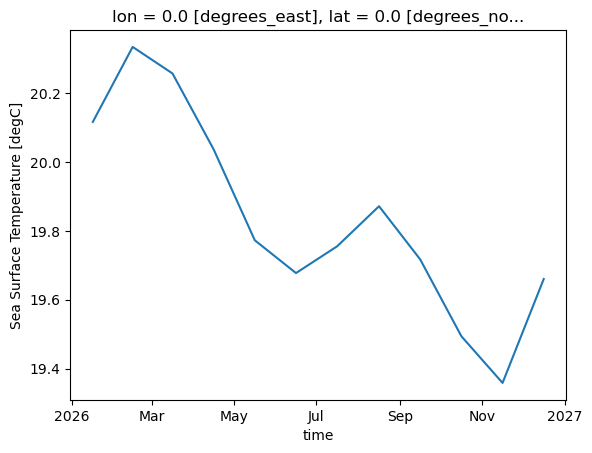

In [22]:
tos_gm["tos"].squeeze().plot()

We can also apply an operator on an xarray object that we've returned earlier (or loaded/generated otherwise)

In [23]:
tos_gm_ymean = cdo.fldmean(input=tos_ds, returnXDataset=True)

In [24]:
tos_gm_ymean["tos"].squeeze().item()

19.837902069091797

# Remapping

Our original data look like this (on a tripolar grid):

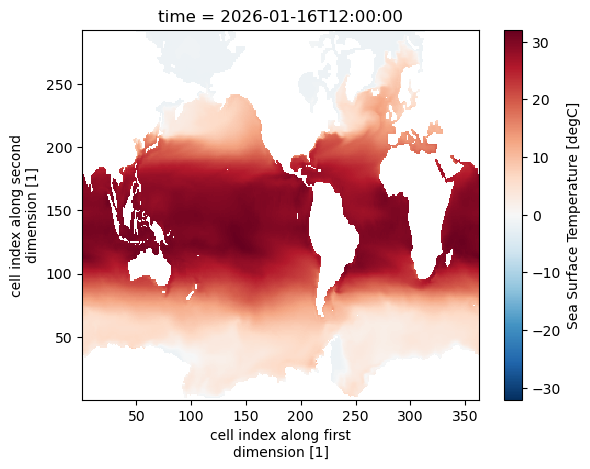

In [25]:
tos.isel(time=0)["tos"].plot()

Now, we want to remap them to a regular 1x1° grid with CDO. There are several interpolation options:

In [26]:
#[key for key, value in cdo.operators.items() if key.startswith('sel')]
[key for key, value in cdo.operators.items() if key.startswith('remap')]

['remap',
 'remapavg',
 'remapavgtest',
 'remapbic',
 'remapbil',
 'remapcon',
 'remapdis',
 'remapeta',
 'remapeta_s',
 'remapeta_z',
 'remapknn',
 'remapkurt',
 'remaplaf',
 'remapmax',
 'remapmean',
 'remapmedian',
 'remapmin',
 'remapnn',
 'remaprange',
 'remapskew',
 'remapstd',
 'remapstd1',
 'remapsum',
 'remapvar',
 'remapvar1',
 'remapycon',
 'remapycon2test']

The most popular/common ones are:

- Nearest-neighbor (`remapnn`)
- Bilinear (`remapbil`)
- Conservative (`remapcon`)

There are multiple ways to specify the grid, see the documentation. Regular grids are named with "r" followed by the number of gridpoints for longitude and latitude:

In [27]:
tos_remap_nn = cdo.remapnn("r360x180", input=fn_tos, returnXDataset=True)

In [28]:
tos_remap_bil = cdo.remapbil("r360x180", input=fn_tos, returnXDataset=True)

In [29]:
tos_remap_cons = cdo.remapcon("r360x180", input=fn_tos, returnXDataset=True)

It is also possible to specify a filename instead of a grid name, then it will remap the data to the grid of that file.

[Text(0.5, 1.0, 'Conservative'), Text(0.5, 0, ''), Text(0, 0.5, '')]

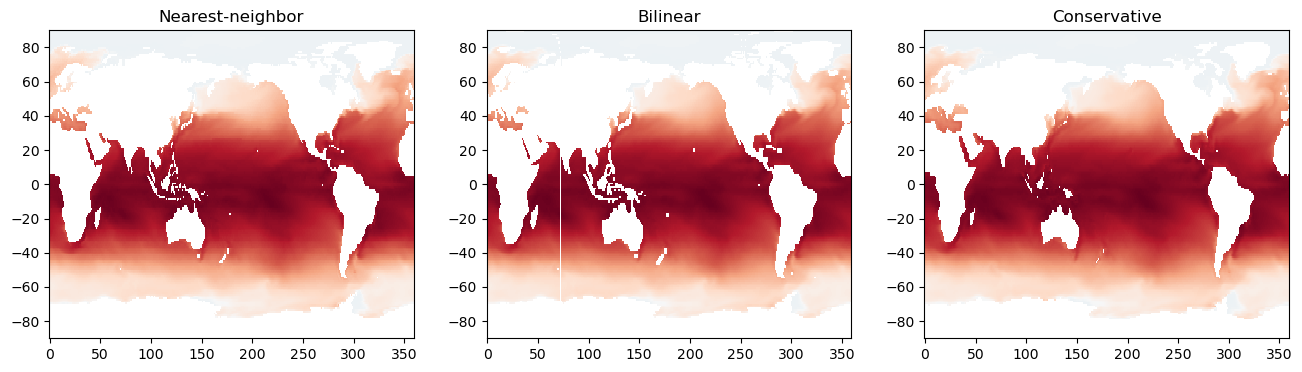

In [30]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
tos_remap_nn["tos"].isel(time=0).plot(ax=axes[0], add_colorbar=False)
axes[0].set(title="Nearest-neighbor", xlabel="", ylabel="")
tos_remap_bil["tos"].isel(time=0).plot(ax=axes[1], add_colorbar=False)
axes[1].set(title="Bilinear", xlabel="", ylabel="")
tos_remap_cons["tos"].isel(time=0).plot(ax=axes[2], add_colorbar=False)
axes[2].set(title="Conservative", xlabel="", ylabel="")

# Interpolation

Similarly, there are several way to fill missing values:

In [31]:
[key for key, value in cdo.operators.items() if key.startswith('setmiss')]

['setmiss', 'setmisstoc', 'setmisstodis', 'setmisstonn', 'setmissval']

We will use a distance-weighted interpolation (on one of the interpolated grids) for demonstration purposes:

In [32]:
tos_filled = cdo.setmisstodis("3", input=tos_remap_bil, returnXDataset=True)

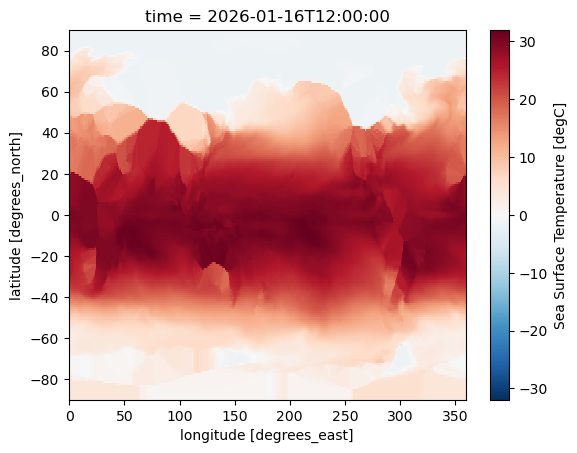

In [33]:
tos_filled["tos"].isel(time=0).plot()

Now, let's generate a land-sea mask from nearest-neighbor remapping of the original data:

In [34]:
lsm_orig = tos.isel(time=0,drop=True).isnull().rename({"tos": "lsm"})
lsm_remapped = cdo.remapnn("r360x180", input=lsm_orig, returnXArray="lsm")

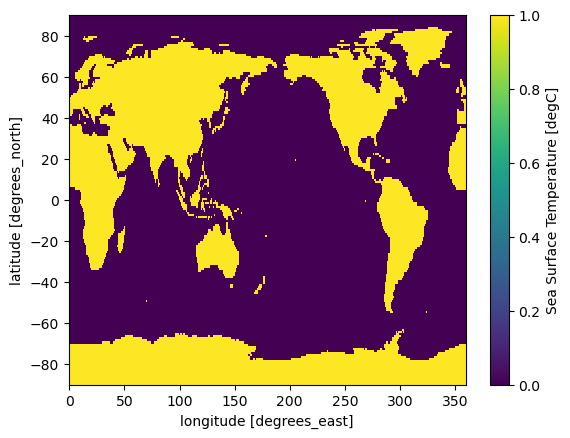

In [35]:
lsm_remapped.plot()

and apply it (this time with xarray) to the remapped and interpolated data:

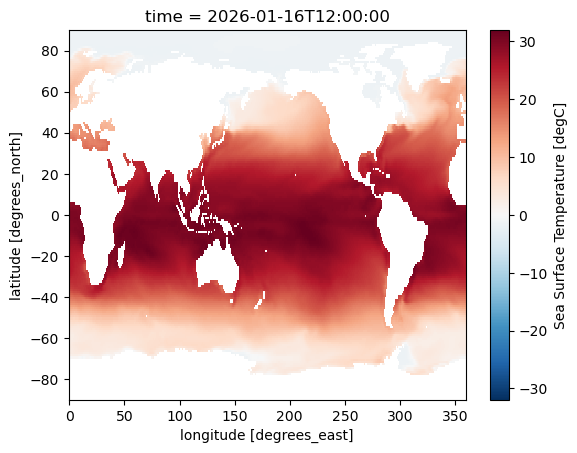

In [36]:
tos_filled["tos"].isel(time=0).where(~lsm_remapped).plot()

# Step-by-step example

As an instructive example, we use 85 years of sea ice concentration future projections simulated by EC-Earth.

## Merging

This model outputs 1 file = 1 year, so we'll first merge all years to a single file.

You can use `cat` (= concatenate) or `mergetime`. Mergetime is safer (it arranges the time axis correctly even if the file names are not in order), but also slower.

We'll write the merged data to a file for easier access later.

In [37]:
fn_sic = "data/siconc_2015-2100.nc"

In [38]:
cdo.mergetime(input="data/siconc_SImon_*.nc", output=fn_sic)

'data/siconc_2015-2100.nc'

In [ ]:
# Alternatively
cdo.cat(input="data/siconc_SImon_*.nc", output=fn_sic)

## Subsetting (temporally)

We can select individual months, for example March (month 3), with the `selmonth` operator:

In [39]:
sic_march = cdo.selmonth("3", input=fn_sic, returnXDataset=True)

## Temporal aggregation

Let's take a seasonal climatology over the entire period with the `ymonmean` operator:

In [40]:
sic_clim = cdo.ymonmean(input=fn_sic, returnXDataset=True)

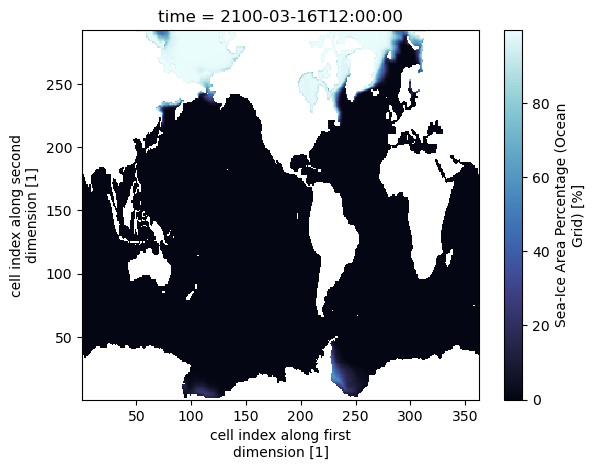

In [41]:
sic_clim["siconc"].isel(time=2).plot(cmap="cmo.ice")

This works with different aggregation methods, not only the mean. For example:

In [42]:
sic_interann_std = cdo.ymonstd(input=fn_sic, returnXDataset=True)

This returns the standard deviation over different years (i.e., the interannual variability) for every month.
    
Of course here this measure doesn't make too much sense because there is also a trend superimposed... We'll see later how to remove that!

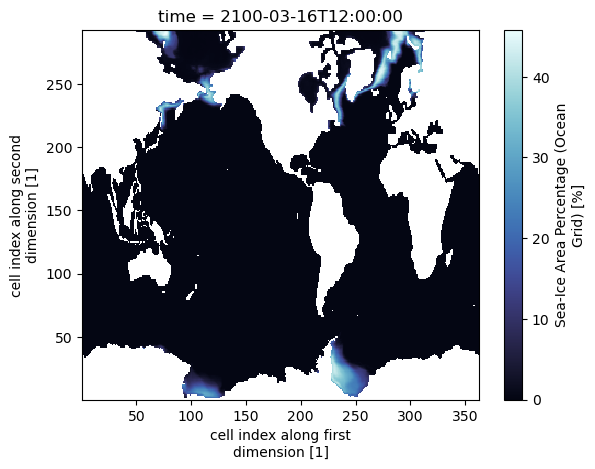

In [43]:
sic_interann_std["siconc"].isel(time=2).plot(cmap="cmo.ice")

## Subsetting (spatially)

Now, let's select only the Northern hemisphere with the `sellonlatbox` operator. It takes four numbers in the following order:

`lon1,lon2,lat1,lat2`

In [44]:
sic_nh = cdo.sellonlatbox("0,360,0,90", input=fn_sic, returnXDataset=True)

This can of course also be applied to the temporal subsets (e.g., the climatology) that we've already computed:

In [45]:
sic_nh_clim = cdo.sellonlatbox("0,360,0,90", input=sic_clim, returnXDataset=True)

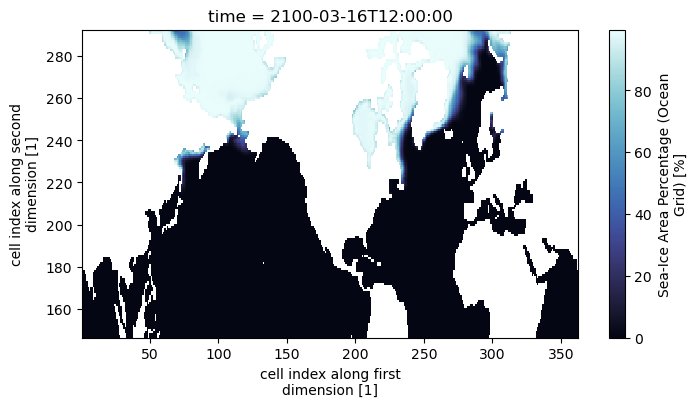

In [46]:
sic_nh_clim["siconc"].isel(time=2).plot(figsize=(8,4), cmap="cmo.ice")

## Operator chaining

Ok, isn't it tiresome having to define so many temporal variables for each operation?

Wouldn't it be much more convenient to get the entire chain of commands into a single line?

Don't despair: That's where operator chaining comes in!

With this, the Northern hemisphere climatology can be calculated from the merged file in a single line:

In [47]:
sic_nh_clim_fldmean = cdo.fldmean(input="-sellonlatbox,0,360,0,90 -ymonmean "+fn_sic, returnXDataset=True)

instead of
```
sic_clim = cdo.ymonmean(input=fn_sic, returnXDataset=True)
sic_nh_clim = cdo.sellonlatbox("0,360,0,90", input=sic_clim, returnXDataset=True)
sic_nh_clim_fldmean = cdo.fldmean(input=sic_nh_clim, returnXDataset=True)
```

**Operators are executed from right to left!**

In this case, we first compute `ymonmean`, then `sellonlatbox` and finally `fldmean`.

This can make quite a difference performance-wise, so choose the order wisely for large datasets.

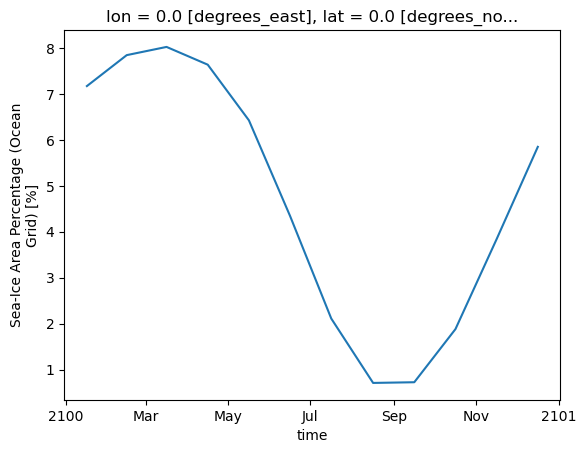

In [48]:
sic_nh_clim_fldmean["siconc"].squeeze().plot()

NB for advanced users:

Normally, merge/concat operations have to be done first, unless you use the `apply` operator
(milage varies, limited to operators without arguments), e.g.:

`sic_gm = cdo.mergetime(input="-apply,fldmean [ data/siconc_SImon_*.nc ]", returnXArray="siconc")`

applies the global mean *before* merging. See the User Guide for more info.

## (Simple) arithmetics

For sea ice, we're usually not interested in the mean concentration but rather in the total ice area. This can be computed (per gridpoint) as follows:

In [50]:
siarea = cdo.expr("'siarea=gridarea(siconc)*siconc/100'", input=fn_sic, returnXDataset=True)

Using operator chaining, we can now calculate the north hemisphere total sea ice area:

In [51]:
siarean = cdo.fldsum(
    input="-sellonlatbox,0,360,0,90 -expr,'siarean=gridarea(siconc)*siconc/100' "+fn_sic,
    output="data/siarean_2015-2100.nc",
    returnXArray="siarean"
)

(NB: `fldsum` is *not* area-weighted by default)

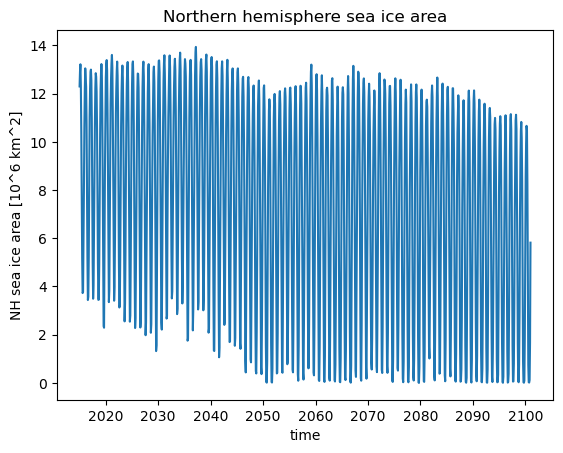

In [52]:
(siarean.squeeze()*1e-12).plot()
plt.title("Northern hemisphere sea ice area")
plt.ylabel("NH sea ice area [10^6 km^2]");

Climatology:

In [53]:
siarean_clim = cdo.ymonmean(input=siarean, returnXArray="siarean")

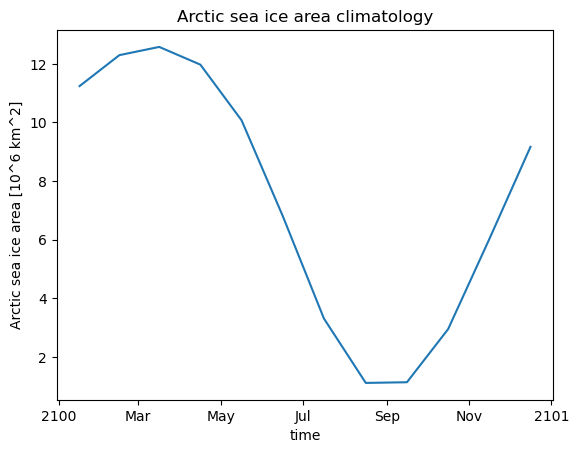

In [54]:
(siarean_clim.squeeze()*1e-12).plot()
plt.title("Arctic sea ice area climatology")
plt.ylabel("Arctic sea ice area [10^6 km^2]");

And finally, a multi-year time series for March and September!

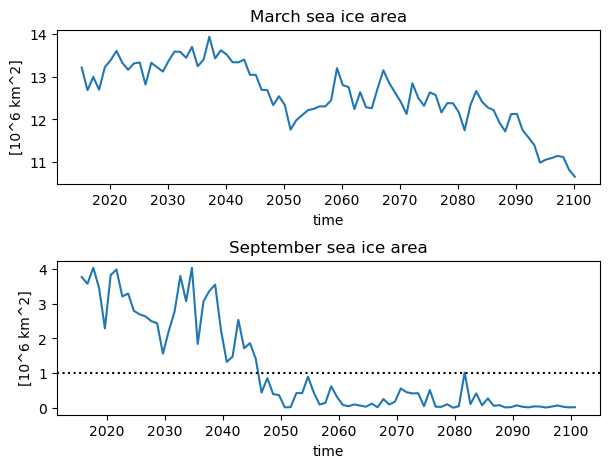

In [55]:
fig, axes = plt.subplots(2,1,figsize=(7,5))
fig.subplots_adjust(hspace=0.5)

(cdo.selmonth("3", input=siarean, returnXArray="siarean")*1e-12).plot(ax=axes[0])
(cdo.selmonth("9", input=siarean, returnXArray="siarean")*1e-12).plot(ax=axes[1])

plt.axhline(1, c="k", ls=":")
axes[0].set_title("March sea ice area")
axes[0].set_ylabel("[10^6 km^2]")
axes[1].set_title("September sea ice area")
axes[1].set_ylabel("[10^6 km^2]");

## Deseasonalizing

Using the operator `ymonsub`:

In [56]:
siarean_deseas = cdo.ymonsub(input="data/siarean_2015-2100.nc -ymonmean data/siarean_2015-2100.nc", returnXArray="siarean")

Or using a low-pass filter (note: preserves the mean):

In [58]:
siarean_lowpass = cdo.lowpass("0.5", input="data/siarean_2015-2100.nc", returnXArray="siarean")

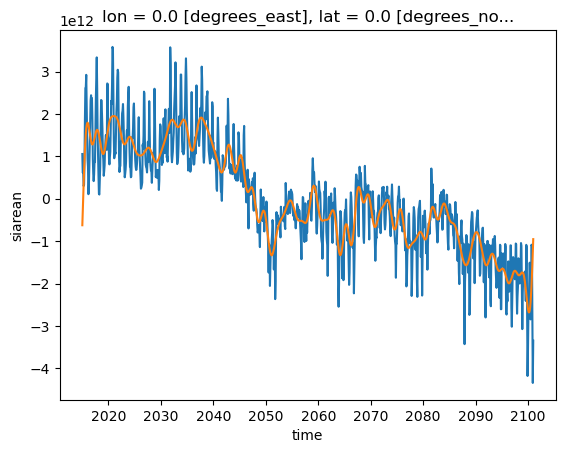

In [59]:
siarean_deseas.plot()
(siarean_lowpass-siarean_lowpass.mean()).plot()

## Detrending

CDO only supports linear detrending (for now).

Let's linearly detrend the March sea ice concentrations that we computed above:

In [60]:
sic_march_detrend = cdo.detrend(input=sic_march, returnXArray="siconc")

And now let's look at where the largest interannual variations are located:

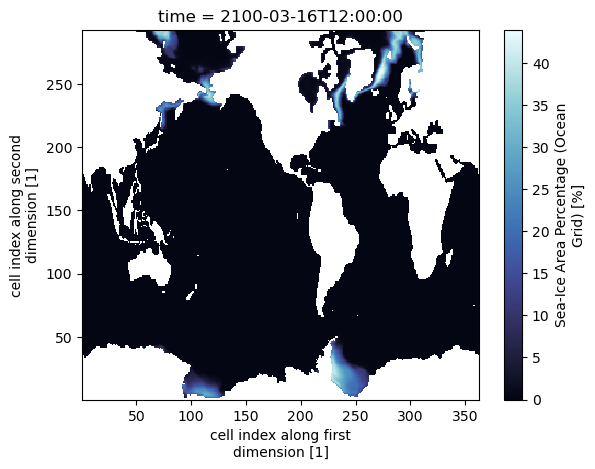

In [61]:
cdo.ymonstd(input=sic_march_detrend, returnXArray="siconc").squeeze().plot(cmap="cmo.ice")

# Appendix: Advanced installation instructions

In some cases, the initialization or the first command with the Python CDO interface fails with a `FileNotFoundError: [Errno 2] No such file or directory: 'cdo'`

For example, this can happen if you're running this notebook from a system-wide Jupyter notebook/lab installation but installed CDO within a dedicated conda environment. In this case it will not be enough to simply use that environment's kernel but additional steps need to be taken:

1. Run `jupyter kernelspec list` to find the location of the Jupyter kernel of the environment in which CDO is installed. Let's call the resulting path `$KERNEL_PATH`.
2. Run `which cdo` inside the (conda) environment containing your CDO installation. This path should end in `bin/cdo`. Let's call the resulting path (including "bin" but excluding "cdo") the `$ENV_PATH`.
3. Open `${KERNEL_PATH}/kernel.json` with a text editor of your choice.
4. Add the following line to the kernel.json file (at the uppermost level):

   ```
   "env": {
     "cdo": "${ENV_PATH}/cdo"
   },
   ```
   where you replace `${ENV_PATH}` with the actual full path.

5. Restart your kernel, if needed.
6. Run the following initialization (again changing ENV_PATH to the actual path from above) within the jupyter notebook:

In [2]:
import os
ENV_PATH = "/Users/Mehli002/miniforge3/envs/cdo_demo/bin"
CDO_PATH = ENV_PATH+"/cdo"

os.environ["PATH"] = ENV_PATH+":"+os.environ["PATH"]

cdo = cdopy.Cdo(cdo=CDO_PATH, tempdir="./tmp")

where again CDO_PATH needs to be replaced with the actual full CDO path.